# 04 · Feature Engineering
### Predicción de Riesgo de Incumplimiento Crediticio · Dataset UCI

---
> **Autor:** Mathias Sebastian Huanca Pretell  
> **Fecha:** 2026  
> **Dataset:** [Default of Credit Card Clients — UCI ML Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)  
> **Notebook:** `04_feature_engineering.ipynb`  
> **Estado:** ✅ Completo

---

**Hoja de ruta del proyecto**

| # | Notebook | Estado |
|---|----------|--------|
| 01 | Entendimiento del Negocio | ✅ Completo |
| 02 | Análisis Exploratorio de Datos (EDA) | ✅ Completo |
| 03 | Preprocesamiento | ✅ Completo |
| 04 | Feature Engineering | ✅ Actual |
| 05 | Modelado y Evaluación | 🔜 |
| 06 | Conclusiones y Recomendaciones | 🔜 |

## Tabla de Contenidos

1. [Objetivo del Feature Engineering](#1-objetivo-del-feature-engineering)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Carga del Dataset Procesado](#3-carga-del-dataset-procesado)
4. [Features de Utilización de Crédito](#4-features-de-utilización-de-crédito)
5. [Features de Comportamiento de Pago](#5-features-de-comportamiento-de-pago)
6. [Features de Tendencia Temporal](#6-features-de-tendencia-temporal)
7. [Features de Mora Acumulada](#7-features-de-mora-acumulada)
8. [Análisis de Importancia de los Nuevos Features](#8-análisis-de-importancia-de-los-nuevos-features)
9. [Selección Final de Features](#9-selección-final-de-features)
10. [Exportación del Dataset Final](#10-exportación-del-dataset-final)

---
## 1. Objetivo del Feature Engineering

El dataset procesado contiene las variables originales limpias y codificadas. El objetivo de este notebook es **crear variables nuevas** que capturen señales de riesgo que las variables originales no expresan directamente.

Todas las features nuevas están fundamentadas en las hipótesis confirmadas en el EDA:

| Grupo | Hipótesis de origen | Features a crear |
|-------|--------------------|-----------------|
| Utilización de crédito | H2 confirmada — utilización alta → mayor riesgo | `UTIL_RATE`, `AVG_UTIL_RATE` |
| Comportamiento de pago | H3 confirmada — pagar menos de lo facturado → mayor riesgo | `PAY_RATIO_1`, `AVG_PAY_RATIO` |
| Tendencia temporal | H3 — tendencia creciente de deuda es señal de deterioro | `BILL_TREND`, `PAY_TREND` |
| Mora acumulada | H1 confirmada — retrasos recurrentes predicen default | `MONTHS_IN_ARREARS`, `MAX_ARREARS`, `RECENT_ARREARS` |
| Capacidad de pago | Combinación H1 + H4 — relación entre pagos y límite | `PAY_TO_LIMIT_RATIO` |

> **Principio guía:** cada feature nueva debe tener una interpretación de negocio clara. No se crean features por volumen — se crean porque hay razón para creer que mejoran la señal predictiva.

---
## 2. Configuración del Entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import jinja2
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
import joblib
import json
import os

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 4)

SEED = 42
np.random.seed(SEED)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 3. Carga del Dataset Procesado

Se carga el dataset exportado por `03_preprocessing.ipynb`. También se carga el dataset crudo para calcular algunos features que requieren los valores originales (antes del escalado y la transformación log1p).

In [3]:
# Dataset procesado (escalado + encoded)
df = pd.read_csv('../data/processed/df_processed.csv')

# Dataset crudo — necesario para calcular ratios en escala original
df_raw = pd.read_excel('../data/raw/default of credit card clients.xls', header=1)
df_raw.rename(columns={'default payment next month': 'TARGET'}, inplace=True)
df_raw.drop(columns=['ID'], inplace=True)

# Aplicar clip de negativos en BILL_AMT (mismo tratamiento que en preprocessing)
bill_cols    = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols = [f'PAY_AMT{i}'  for i in range(1, 7)]
pay_sts_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in bill_cols:
    df_raw[col] = df_raw[col].clip(lower=0)

print(f'Dataset procesado:  {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Dataset crudo:      {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Columnas procesadas: {list(df.columns)}')

Dataset procesado:  30,000 filas × 27 columnas
Dataset crudo:      30,000 filas × 24 columnas
Columnas procesadas: ['LIMIT_BAL', 'SEX', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'TARGET', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


---
## 4. Features de Utilización de Crédito

### Concepto
La **tasa de utilización** mide qué fracción del límite de crédito disponible está siendo usada. Es una de las señales más directas de presión financiera: un cliente que usa el 90% de su límite tiene mucho menos margen que uno que usa el 20%.

Se calculan sobre los valores crudos (pre-escalado) para que los ratios sean interpretables.

Features de utilización creados:
  UTIL_RATE_1 a UTIL_RATE_6  — utilización mensual
  AVG_UTIL_RATE              — promedio 6 meses
  MAX_UTIL_RATE              — pico máximo 6 meses


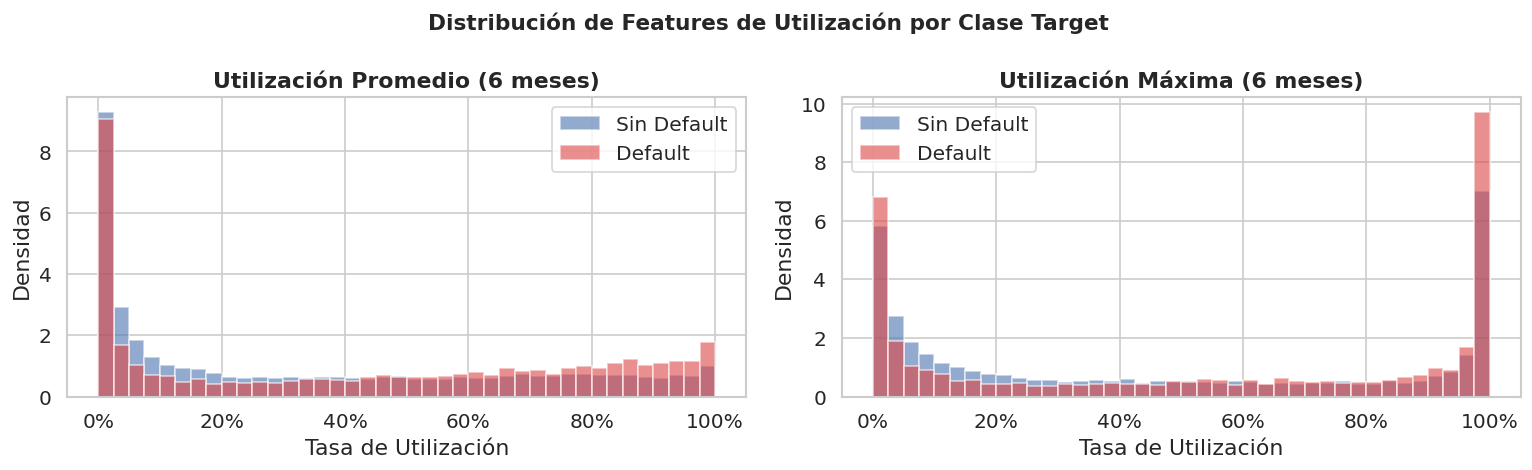


Tasa de default por quintil de AVG_UTIL_RATE:
_quintil_util
Q1    22.6%
Q2    14.3%
Q3    17.7%
Q4    24.7%
Q5    31.3%


In [4]:
# UTIL_RATE_X: tasa de utilización mensual = BILL_AMTx / LIMIT_BAL
# Cap a 1.0 — utilización > 100% es posible (intereses) pero distorsiona la escala
util_cols = []
for i in range(1, 7):
    col = f'UTIL_RATE_{i}'
    df[col] = (df_raw[f'BILL_AMT{i}'] / df_raw['LIMIT_BAL'].replace(0, np.nan)).fillna(0).clip(0, 1)
    util_cols.append(col)

# AVG_UTIL_RATE: promedio de utilización en los 6 meses
df['AVG_UTIL_RATE'] = df[util_cols].mean(axis=1)

# MAX_UTIL_RATE: pico máximo de utilización en los 6 meses
df['MAX_UTIL_RATE'] = df[util_cols].max(axis=1)

print('Features de utilización creados:')
print(f'  UTIL_RATE_1 a UTIL_RATE_6  — utilización mensual')
print(f'  AVG_UTIL_RATE              — promedio 6 meses')
print(f'  MAX_UTIL_RATE              — pico máximo 6 meses')

# Visualización: distribución por clase target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
    ['AVG_UTIL_RATE', 'MAX_UTIL_RATE'],
    ['Utilización Promedio (6 meses)', 'Utilización Máxima (6 meses)']):
    for t, label, color in [(0, 'Sin Default', '#4C72B0'), (1, 'Default', '#DD4444')]:
        ax.hist(df[df['TARGET'] == t][col], bins=40, alpha=0.6,
                color=color, label=label, density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Tasa de Utilización')
    ax.set_ylabel('Densidad')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend()

plt.suptitle('Distribución de Features de Utilización por Clase Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tasa de default por quintil de AVG_UTIL_RATE
df['_quintil_util'] = pd.qcut(df['AVG_UTIL_RATE'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'], duplicates='drop')
print('\nTasa de default por quintil de AVG_UTIL_RATE:')
print(df.groupby('_quintil_util', observed=True)['TARGET'].mean().map('{:.1%}'.format).to_string())
df.drop(columns='_quintil_util', inplace=True)

---
## 5. Features de Comportamiento de Pago

### Concepto
El **ratio de pago** mide qué fracción del saldo facturado pagó el cliente. Un cliente que paga consistentemente menos del 10% de su saldo está acumulando deuda progresivamente — señal directa de deterioro financiero.

También se calcula la **brecha absoluta** (cuánto dejó de pagar en pesos), que captura la magnitud del problema más allá del porcentaje.

Features de comportamiento de pago creados:
  PAY_RATIO_1 a PAY_RATIO_6  — fracción del saldo pagada mensualmente
  AVG_PAY_RATIO              — promedio 6 meses
  MIN_PAY_RATIO              — peor mes de pago
  UNPAID_BAL_1               — saldo sin pagar en el mes más reciente (log1p)


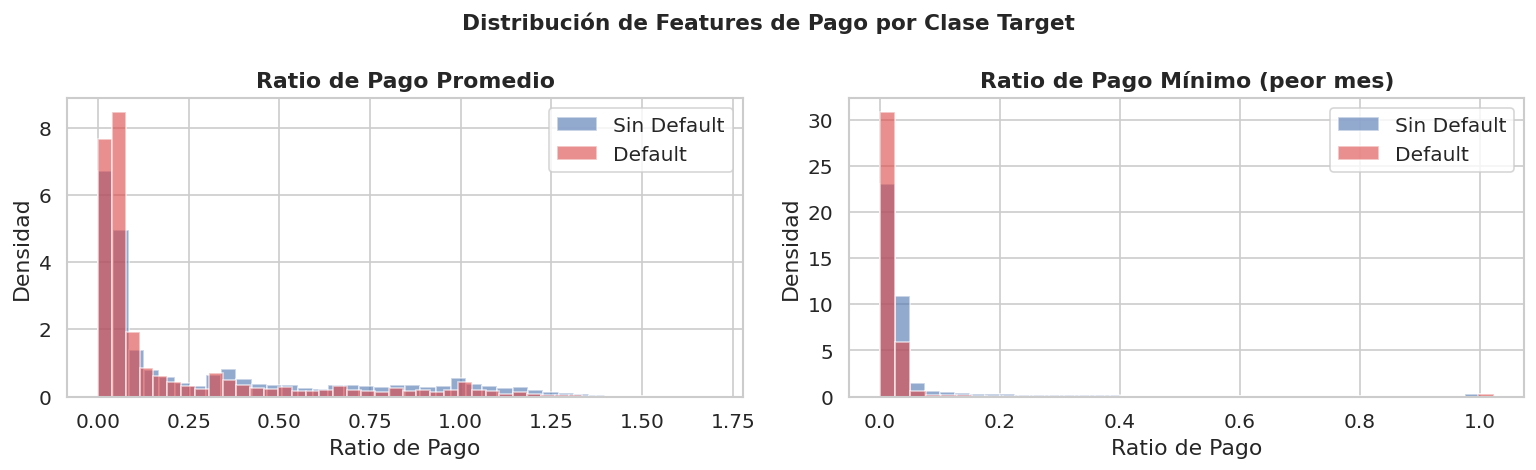


Tasa de default por quintil de AVG_PAY_RATIO (Q1=paga menos):
_quintil_pay
Q1    29.4%
Q2    24.2%
Q3    25.5%
Q4    17.7%
Q5    13.8%


In [5]:
# PAY_RATIO_X: fracción del saldo pagada cada mes
pay_ratio_cols = []
for i in range(1, 7):
    col = f'PAY_RATIO_{i}'
    bill = df_raw[f'BILL_AMT{i}'].replace(0, np.nan)
    df[col] = (df_raw[f'PAY_AMT{i}'] / bill).fillna(0).clip(0, 2)
    pay_ratio_cols.append(col)

# AVG_PAY_RATIO: promedio del ratio de pago en 6 meses
df['AVG_PAY_RATIO'] = df[pay_ratio_cols].mean(axis=1)

# MIN_PAY_RATIO: el mes en que peor pagó — captura el peor momento
df['MIN_PAY_RATIO'] = df[pay_ratio_cols].min(axis=1)

# UNPAID_BAL_1: brecha absoluta en el mes más reciente (cuánto dejó sin pagar)
df['UNPAID_BAL_1'] = np.log1p((df_raw['BILL_AMT1'] - df_raw['PAY_AMT1']).clip(lower=0))

print('Features de comportamiento de pago creados:')
print('  PAY_RATIO_1 a PAY_RATIO_6  — fracción del saldo pagada mensualmente')
print('  AVG_PAY_RATIO              — promedio 6 meses')
print('  MIN_PAY_RATIO              — peor mes de pago')
print('  UNPAID_BAL_1               — saldo sin pagar en el mes más reciente (log1p)')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
    ['AVG_PAY_RATIO', 'MIN_PAY_RATIO'],
    ['Ratio de Pago Promedio', 'Ratio de Pago Mínimo (peor mes)']):
    for t, label, color in [(0, 'Sin Default', '#4C72B0'), (1, 'Default', '#DD4444')]:
        ax.hist(df[df['TARGET'] == t][col], bins=40, alpha=0.6,
                color=color, label=label, density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Ratio de Pago')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Distribución de Features de Pago por Clase Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tasa de default por quintil
df['_quintil_pay'] = pd.qcut(df['AVG_PAY_RATIO'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'], duplicates='drop')
print('\nTasa de default por quintil de AVG_PAY_RATIO (Q1=paga menos):')
print(df.groupby('_quintil_pay', observed=True)['TARGET'].mean().map('{:.1%}'.format).to_string())
df.drop(columns='_quintil_pay', inplace=True)

---
## 6. Features de Tendencia Temporal

### Concepto
Las variables `BILL_AMT` y `PAY_AMT` registran 6 meses de historial. Una tendencia **creciente** en el saldo (la deuda aumenta mes a mes) es una señal de deterioro más informativa que el saldo absoluto en un momento dado. Igualmente, una tendencia **decreciente** en los pagos indica que el cliente está pagando cada vez menos.

Se usa la **pendiente de regresión lineal** sobre los 6 meses como medida de tendencia — es más robusta que la simple diferencia entre el primer y último mes porque usa toda la información disponible.

Calculando BILL_TREND (puede tardar unos segundos)...
Calculando PAY_TREND...
Features de tendencia creados:
  BILL_TREND — pendiente del saldo (log-signed): positivo = deuda creciente
  PAY_TREND  — pendiente del pago  (log-signed): negativo = pagos decrecientes


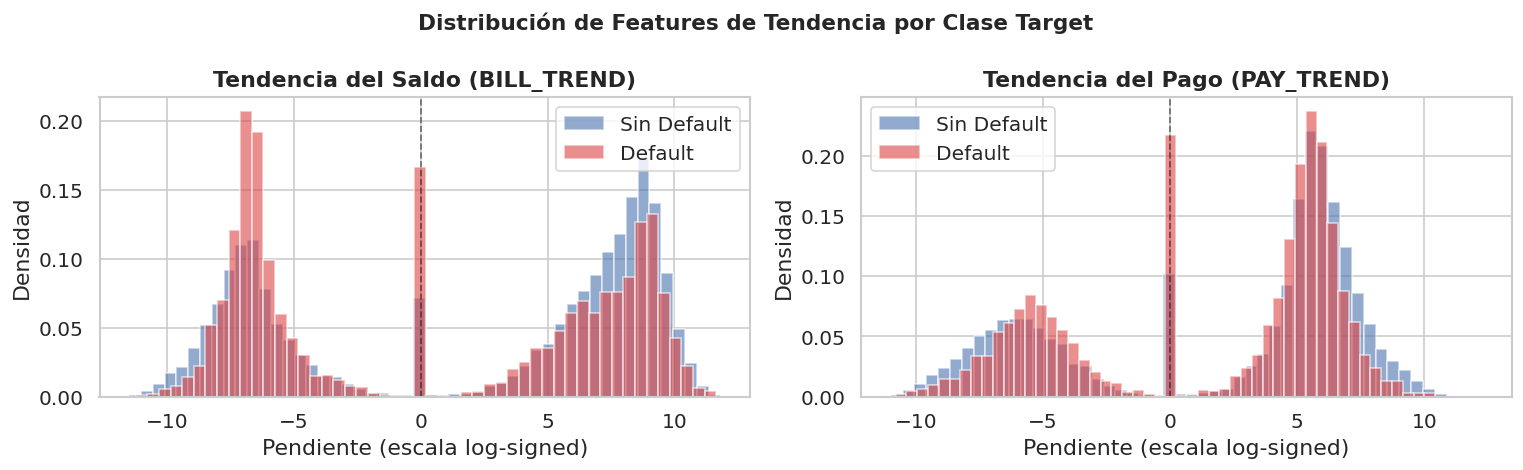

  Correlación BILL_TREND vs TARGET: -0.0860
  Correlación PAY_TREND vs TARGET: -0.0309


In [6]:
# Función auxiliar: pendiente de regresión lineal sobre una ventana de valores
def linear_slope(row):
    """Calcula la pendiente de la regresión lineal de una serie de 6 valores.
    Valor positivo = tendencia creciente, negativo = decreciente."""
    x = np.arange(len(row))
    if row.std() == 0:
        return 0.0
    slope = np.polyfit(x, row, 1)[0]
    return slope

# BILL_TREND: pendiente del saldo en los 6 meses (valores originales)
# Nota: BILL_AMT1 es el más reciente, BILL_AMT6 el más antiguo
# Se invierte el orden para que la tendencia vaya de pasado a presente
bill_ordered = [f'BILL_AMT{i}' for i in range(6, 0, -1)]  # 6 → 1
pay_ordered  = [f'PAY_AMT{i}'  for i in range(6, 0, -1)]

print('Calculando BILL_TREND (puede tardar unos segundos)...')
df['BILL_TREND'] = df_raw[bill_ordered].apply(linear_slope, axis=1)
df['BILL_TREND'] = np.sign(df['BILL_TREND']) * np.log1p(np.abs(df['BILL_TREND']))

print('Calculando PAY_TREND...')
df['PAY_TREND'] = df_raw[pay_ordered].apply(linear_slope, axis=1)
df['PAY_TREND'] = np.sign(df['PAY_TREND']) * np.log1p(np.abs(df['PAY_TREND']))

print('Features de tendencia creados:')
print(f'  BILL_TREND — pendiente del saldo (log-signed): positivo = deuda creciente')
print(f'  PAY_TREND  — pendiente del pago  (log-signed): negativo = pagos decrecientes')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
    ['BILL_TREND', 'PAY_TREND'],
    ['Tendencia del Saldo (BILL_TREND)', 'Tendencia del Pago (PAY_TREND)']):
    for t, label, color in [(0, 'Sin Default', '#4C72B0'), (1, 'Default', '#DD4444')]:
        ax.hist(df[df['TARGET'] == t][col], bins=50, alpha=0.6,
                color=color, label=label, density=True)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Pendiente (escala log-signed)')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Distribución de Features de Tendencia por Clase Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación con target
for col in ['BILL_TREND', 'PAY_TREND']:
    r = df[col].corr(df['TARGET'])
    print(f'  Correlación {col} vs TARGET: {r:.4f}')

---
## 7. Features de Mora Acumulada

### Concepto
Las variables `PAY_X` registran el estado de pago de cada mes individualmente. Pero un cliente que estuvo en mora **3 meses de los últimos 6** es más riesgoso que uno que tuvo mora solo 1 mes — aunque ambos tengan `PAY_0 = 1`. Estos features capturan esa dimensión acumulada.

Features de mora acumulada creados:
  MONTHS_IN_ARREARS  — meses en mora en los últimos 6
  MAX_ARREARS        — peor nivel de retraso registrado
  RECENT_ARREARS     — mora ponderada (reciente pesa más)
  EVER_IN_ARREARS    — flag binario: alguna vez en mora


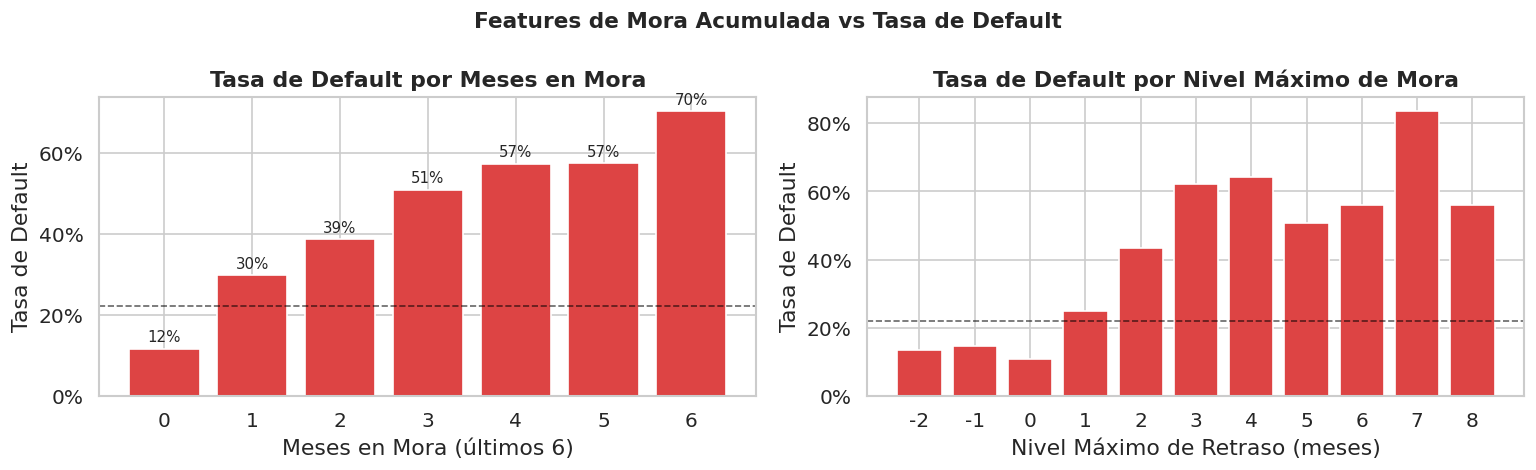


Tasa de default por EVER_IN_ARREARS:
EVER_IN_ARREARS
0    11.7%
1    42.7%


In [7]:
# MONTHS_IN_ARREARS: cantidad de meses con retraso (PAY_X >= 1) en los últimos 6
df['MONTHS_IN_ARREARS'] = (df_raw[pay_sts_cols] >= 1).sum(axis=1)

# MAX_ARREARS: máximo nivel de retraso registrado (peor mes)
df['MAX_ARREARS'] = df_raw[pay_sts_cols].max(axis=1)

# RECENT_ARREARS: suma ponderada de mora — los meses recientes pesan más
# Pesos: PAY_0=6, PAY_2=5, PAY_3=4, PAY_4=3, PAY_5=2, PAY_6=1
weights = np.array([6, 5, 4, 3, 2, 1])
pay_sts_values = df_raw[pay_sts_cols].clip(lower=0).values  # solo meses en mora
df['RECENT_ARREARS'] = (pay_sts_values * weights).sum(axis=1)

# EVER_IN_ARREARS: flag binario — ¿estuvo alguna vez en mora en los últimos 6 meses?
df['EVER_IN_ARREARS'] = (df['MONTHS_IN_ARREARS'] > 0).astype(int)

print('Features de mora acumulada creados:')
print('  MONTHS_IN_ARREARS  — meses en mora en los últimos 6')
print('  MAX_ARREARS        — peor nivel de retraso registrado')
print('  RECENT_ARREARS     — mora ponderada (reciente pesa más)')
print('  EVER_IN_ARREARS    — flag binario: alguna vez en mora')

# Tasa de default por cantidad de meses en mora
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

arrears_rate = df.groupby('MONTHS_IN_ARREARS')['TARGET'].mean().reset_index()
axes[0].bar(arrears_rate['MONTHS_IN_ARREARS'], arrears_rate['TARGET'],
            color='#DD4444', edgecolor='white')
axes[0].axhline(df['TARGET'].mean(), color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title('Tasa de Default por Meses en Mora', fontweight='bold')
axes[0].set_xlabel('Meses en Mora (últimos 6)')
axes[0].set_ylabel('Tasa de Default')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, v in zip(axes[0].patches, arrears_rate['TARGET']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.0%}', ha='center', va='bottom', fontsize=9)

max_rate = df.groupby('MAX_ARREARS')['TARGET'].mean().reset_index()
axes[1].bar(max_rate['MAX_ARREARS'].astype(str), max_rate['TARGET'],
            color='#DD4444', edgecolor='white')
axes[1].axhline(df['TARGET'].mean(), color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Tasa de Default por Nivel Máximo de Mora', fontweight='bold')
axes[1].set_xlabel('Nivel Máximo de Retraso (meses)')
axes[1].set_ylabel('Tasa de Default')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Features de Mora Acumulada vs Tasa de Default', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTasa de default por EVER_IN_ARREARS:')
print(df.groupby('EVER_IN_ARREARS')['TARGET'].mean().map('{:.1%}'.format).to_string())

---
### Feature adicional: Capacidad de Pago Relativa

### Concepto
El ratio entre el pago promedio realizado y el límite de crédito captura cuánto está pagando el cliente en relación a su capacidad crediticia asignada. Un cliente con límite de 500K que paga 5K por mes está en una posición muy distinta a uno con límite de 50K que paga 5K.

In [8]:
# PAY_TO_LIMIT_RATIO: pago promedio mensual / límite de crédito
avg_pay_raw = df_raw[pay_amt_cols].mean(axis=1)
df['PAY_TO_LIMIT_RATIO'] = (avg_pay_raw / df_raw['LIMIT_BAL'].replace(0, np.nan)).fillna(0).clip(0, 1)
df['PAY_TO_LIMIT_RATIO'] = np.log1p(df['PAY_TO_LIMIT_RATIO'])

r = df['PAY_TO_LIMIT_RATIO'].corr(df['TARGET'])
print(f'PAY_TO_LIMIT_RATIO creado.')
print(f'Correlación con TARGET: {r:.4f}')

PAY_TO_LIMIT_RATIO creado.
Correlación con TARGET: -0.0410


---
## 8. Análisis de Importancia de los Nuevos Features

Se entrena un RandomForest rápido (sin optimización) para obtener una estimación de la importancia relativa de todos los features — tanto originales como nuevos. El objetivo no es obtener el mejor modelo, sino comparar si los features creados aportan señal real.

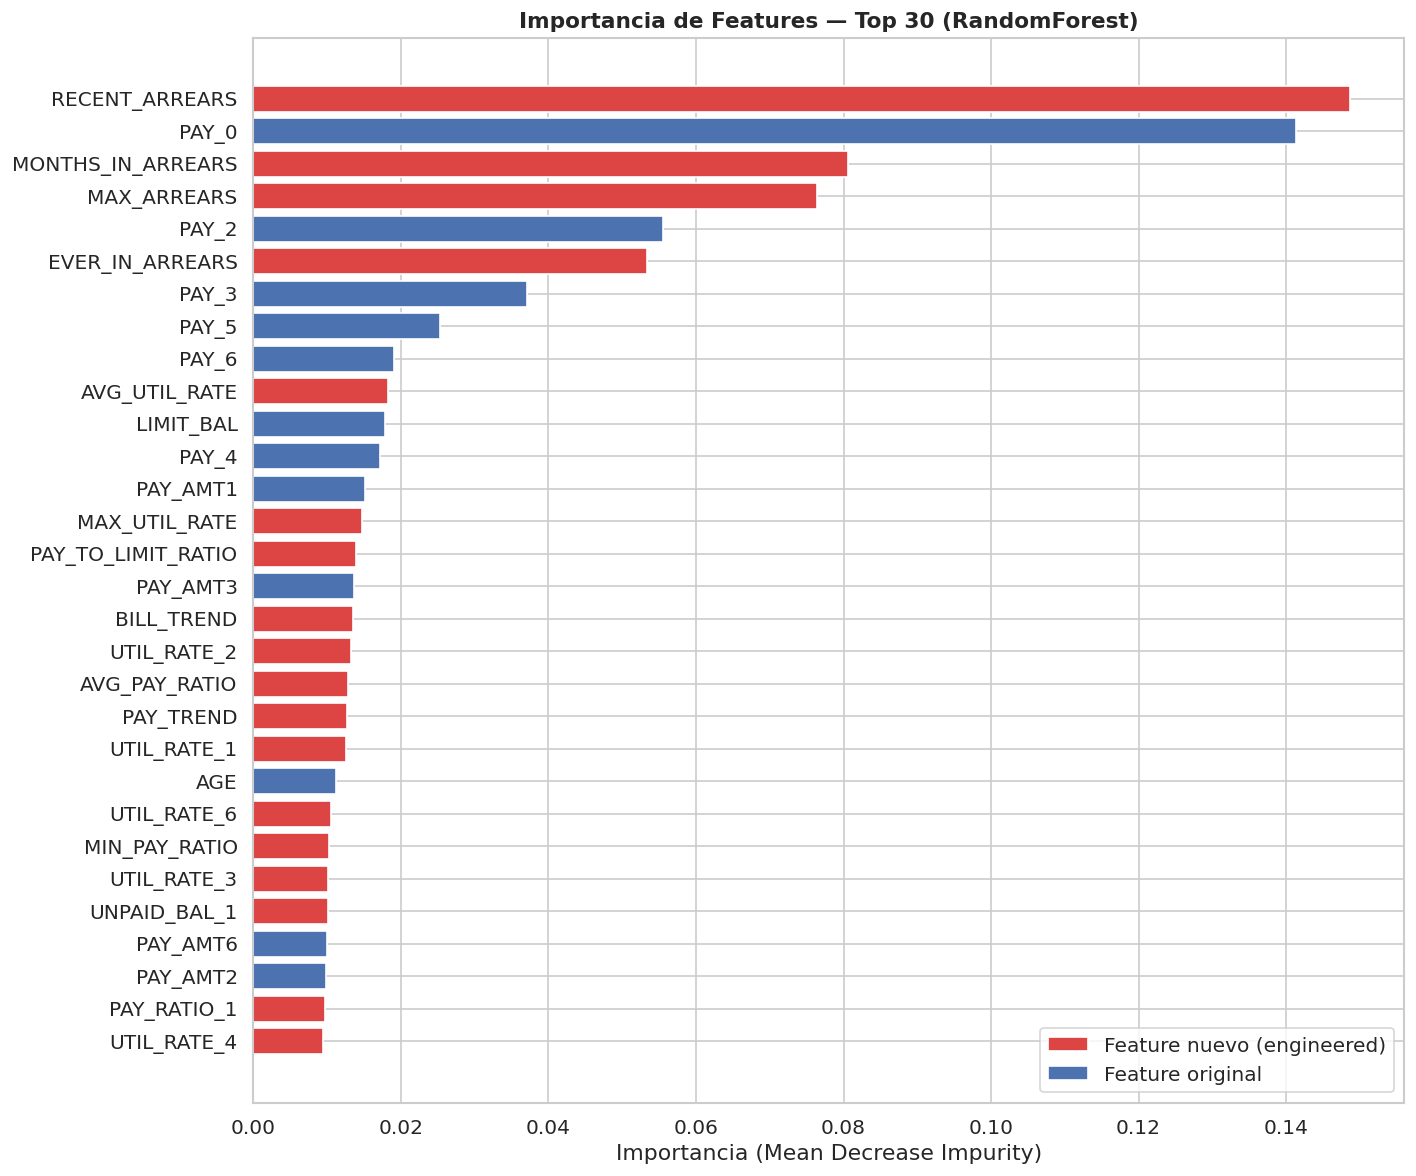


Top 10 features por importancia:
          Feature  Importancia             Tipo
   RECENT_ARREARS     0.148627    Feature nuevo
            PAY_0     0.141308 Feature original
MONTHS_IN_ARREARS     0.080573    Feature nuevo
      MAX_ARREARS     0.076458    Feature nuevo
            PAY_2     0.055578 Feature original
  EVER_IN_ARREARS     0.053400    Feature nuevo
            PAY_3     0.037145 Feature original
            PAY_5     0.025313 Feature original
            PAY_6     0.019045 Feature original
    AVG_UTIL_RATE     0.018211    Feature nuevo


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='TARGET')
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# RandomForest rápido solo para importancias
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

# Marcar features nuevos
new_features = (
    [f'UTIL_RATE_{i}' for i in range(1, 7)] +
    ['AVG_UTIL_RATE', 'MAX_UTIL_RATE'] +
    [f'PAY_RATIO_{i}' for i in range(1, 7)] +
    ['AVG_PAY_RATIO', 'MIN_PAY_RATIO', 'UNPAID_BAL_1'] +
    ['BILL_TREND', 'PAY_TREND'] +
    ['MONTHS_IN_ARREARS', 'MAX_ARREARS', 'RECENT_ARREARS', 'EVER_IN_ARREARS'] +
    ['PAY_TO_LIMIT_RATIO']
)
importance_df['Tipo'] = importance_df['Feature'].apply(
    lambda x: 'Feature nuevo' if x in new_features else 'Feature original'
)

# Top 30
top30 = importance_df.head(30)
colors = ['#DD4444' if t == 'Feature nuevo' else '#4C72B0' for t in top30['Tipo']]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(top30['Feature'][::-1], top30['Importancia'][::-1],
               color=colors[::-1], edgecolor='white')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#DD4444', label='Feature nuevo (engineered)'),
    Patch(facecolor='#4C72B0', label='Feature original')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_title('Importancia de Features — Top 30 (RandomForest)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia (Mean Decrease Impurity)')
plt.tight_layout()
plt.show()

print('\nTop 10 features por importancia:')
print(importance_df[['Feature', 'Importancia', 'Tipo']].head(10).to_string(index=False))

---
## 9. Selección Final de Features

Se eliminan features con importancia muy baja o que generan redundancia excesiva. El criterio de corte es doble:
- **Importancia < 0.005** en el RandomForest (umbral de ruido)
- **Correlación > 0.95** con otro feature del mismo grupo (redundancia)

In [10]:
# ── Eliminar features con importancia muy baja ───────────────────────
IMPORTANCE_THRESHOLD = 0.005

low_importance = importance_df[importance_df['Importancia'] < IMPORTANCE_THRESHOLD]['Feature'].tolist()
print(f'Features con importancia < {IMPORTANCE_THRESHOLD}:')
print(low_importance if low_importance else '  Ninguno — todos superan el umbral.')

if low_importance:
    df.drop(columns=low_importance, inplace=True)
    print(f'  → Eliminados: {len(low_importance)} features')

# ── Detectar correlaciones muy altas entre features nuevos ───────────
new_feat_present = [f for f in new_features if f in df.columns]
corr_new = df[new_feat_present].corr().abs()

# Extraer pares con correlación > 0.95
upper = corr_new.where(np.triu(np.ones(corr_new.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95]

if high_corr_pairs:
    print(f'\nPares de features nuevos con correlación > 0.95:')
    to_drop_corr = set()
    for f1, f2, corr_val in high_corr_pairs:
        # Mantener el de mayor importancia
        imp_f1 = importance_df[importance_df['Feature'] == f1]['Importancia'].values
        imp_f2 = importance_df[importance_df['Feature'] == f2]['Importancia'].values
        drop = f2 if (len(imp_f1) > 0 and len(imp_f2) > 0 and imp_f1[0] >= imp_f2[0]) else f1
        to_drop_corr.add(drop)
        print(f'  {f1} ↔ {f2}: {corr_val:.3f} → se elimina {drop}')
    df.drop(columns=list(to_drop_corr), inplace=True, errors='ignore')
else:
    print('\nSin correlaciones > 0.95 entre features nuevos — todos se conservan.')

print(f'\n📐 Dimensiones finales del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Features totales para modelado: {df.shape[1] - 1} (excluyendo TARGET)')

Features con importancia < 0.005:
['BILL_AMT4', 'BILL_AMT3', 'BILL_AMT6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT5', 'EDUCATION_2', 'SEX', 'MARRIAGE_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_3']
  → Eliminados: 12 features

Pares de features nuevos con correlación > 0.95:
  AVG_UTIL_RATE ↔ UTIL_RATE_3: 0.962 → se elimina UTIL_RATE_3
  AVG_UTIL_RATE ↔ UTIL_RATE_4: 0.956 → se elimina UTIL_RATE_4

📐 Dimensiones finales del dataset: 30,000 filas × 37 columnas
Features totales para modelado: 36 (excluyendo TARGET)


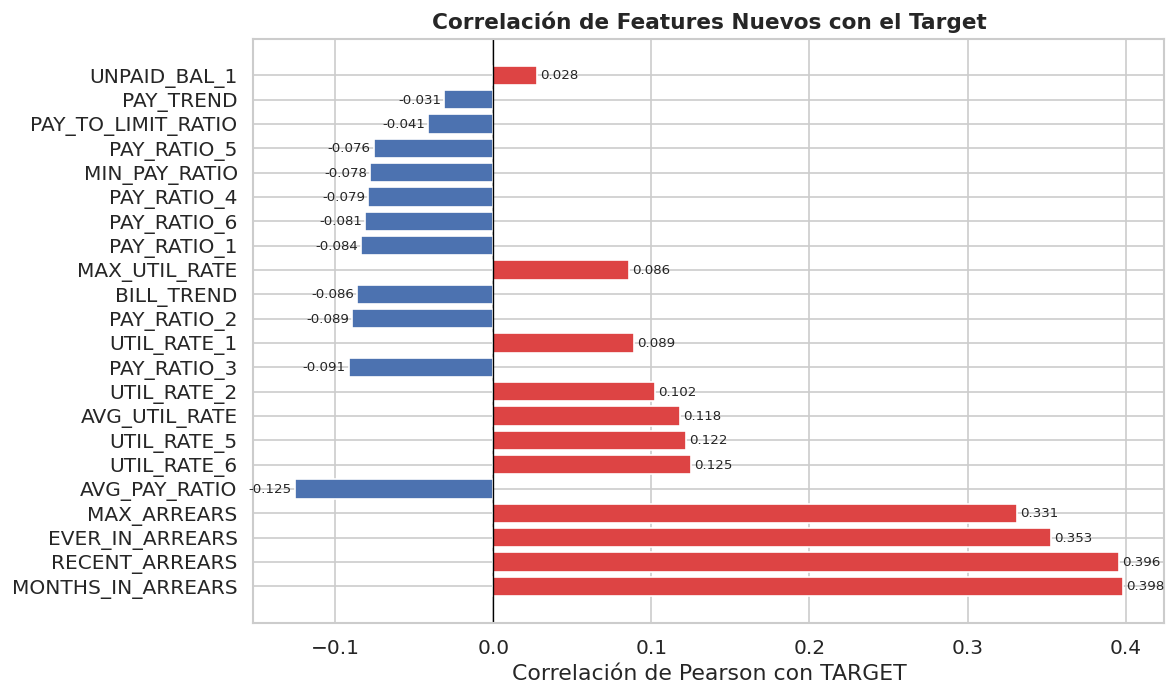

In [11]:
# Heatmap de correlación de los features nuevos finales con el target
new_feat_final = [f for f in new_features if f in df.columns]
corr_with_target = df[new_feat_final + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD4444' if v > 0 else '#4C72B0' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con TARGET')
ax.set_title('Correlación de Features Nuevos con el Target', fontweight='bold', fontsize=13)
for i, (idx, v) in enumerate(corr_with_target.items()):
    ax.text(v + (0.002 if v >= 0 else -0.002), i,
            f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 10. Exportación del Dataset Final

Se exporta el dataset con todos los features originales procesados más los features nuevos. Este es el dataset que ingresa directamente al notebook de modelado.

In [12]:
os.makedirs('../data/processed', exist_ok=True)

output_path = '../data/processed/df_features.csv'
df.to_csv(output_path, index=False)

# Guardar lista de features finales para referencia en modelado
feature_cols = [c for c in df.columns if c != 'TARGET']
with open('../data/processed/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

print(f'✅ Dataset con features exportado a: {output_path}')
print(f'   {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Features para modelado: {len(feature_cols)}')
print(f'✅ Lista de features exportada a: ../data/processed/feature_cols.json')

print('\n📋 Resumen de features nuevos creados y conservados:')
new_feat_final = [f for f in new_features if f in df.columns]
print(f'   Total features nuevos: {len(new_feat_final)}')
for f in new_feat_final:
    imp = importance_df[importance_df['Feature'] == f]['Importancia'].values
    imp_str = f'{imp[0]:.4f}' if len(imp) > 0 else 'N/A'
    print(f'   {f:<25} importancia RF: {imp_str}')

print(f'\n📁 Archivos en ../data/processed/:')
for fname in os.listdir('../data/processed/'):
    size = os.path.getsize(f'../data/processed/{fname}')
    print(f'   {fname} ({size/1024:.1f} KB)')

✅ Dataset con features exportado a: ../data/processed/df_features.csv
   30,000 filas × 37 columnas
   Features para modelado: 36
✅ Lista de features exportada a: ../data/processed/feature_cols.json

📋 Resumen de features nuevos creados y conservados:
   Total features nuevos: 22
   UTIL_RATE_1               importancia RF: 0.0125
   UTIL_RATE_2               importancia RF: 0.0133
   UTIL_RATE_5               importancia RF: 0.0089
   UTIL_RATE_6               importancia RF: 0.0105
   AVG_UTIL_RATE             importancia RF: 0.0182
   MAX_UTIL_RATE             importancia RF: 0.0147
   PAY_RATIO_1               importancia RF: 0.0097
   PAY_RATIO_2               importancia RF: 0.0069
   PAY_RATIO_3               importancia RF: 0.0093
   PAY_RATIO_4               importancia RF: 0.0077
   PAY_RATIO_5               importancia RF: 0.0063
   PAY_RATIO_6               importancia RF: 0.0074
   AVG_PAY_RATIO             importancia RF: 0.0129
   MIN_PAY_RATIO             importancia RF

---
### Resumen de Features Creados

| Feature | Fórmula / Descripción | Hipótesis de origen | Escala |
|---------|----------------------|--------------------|---------|
| `UTIL_RATE_1–6` | `BILL_AMTx / LIMIT_BAL` | H2 | [0, 1] |
| `AVG_UTIL_RATE` | Media de UTIL_RATE_1–6 | H2 | [0, 1] |
| `MAX_UTIL_RATE` | Máximo de UTIL_RATE_1–6 | H2 | [0, 1] |
| `PAY_RATIO_1–6` | `PAY_AMTx / BILL_AMTx` | H3 | [0, 2] |
| `AVG_PAY_RATIO` | Media de PAY_RATIO_1–6 | H3 | [0, 2] |
| `MIN_PAY_RATIO` | Mínimo de PAY_RATIO_1–6 | H3 | [0, 2] |
| `UNPAID_BAL_1` | `log1p(BILL_AMT1 - PAY_AMT1)` | H3 | log1p |
| `BILL_TREND` | Pendiente log-signed del saldo 6m | H3 | log-signed |
| `PAY_TREND` | Pendiente log-signed del pago 6m | H3 | log-signed |
| `MONTHS_IN_ARREARS` | Meses con PAY_X ≥ 1 | H1 | [0, 6] |
| `MAX_ARREARS` | Máximo valor de PAY_X | H1 | [-2, 9] |
| `RECENT_ARREARS` | Mora ponderada (reciente × 6…1) | H1 | continuo |
| `EVER_IN_ARREARS` | Flag: alguna vez en mora | H1 | {0, 1} |
| `PAY_TO_LIMIT_RATIO` | `log1p(avg(PAY_AMT) / LIMIT_BAL)` | H1+H4 | log1p |

---
*Fin del Feature Engineering — continuar con `05_modeling.ipynb`*